# Cu_kPa Modeling Notebook

This notebook trains a dedicated regression workflow for the undrained shear-strength target `Cu_kPa`.

Workflow:
1. Load the dense target-specific CSV prepared during harmonization.
2. Verify that the remaining deterministic soil relationships are understood before modeling.
3. Build `Cu_kPa`-specific engineered features focused on plasticity, density, and consolidation response.
4. Compare 6 regression models using 5-fold shuffled cross-validation.
5. Diagnose the best model with parity, residual, and permutation-importance plots.
6. Export the model comparison table, OOF predictions, feature importance, and fitted best model.

In [11]:
# Standard library imports
from pathlib import Path
import warnings

# Data manipulation and notebook display helpers
import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    from sklearn.ensemble import AdaBoostRegressor
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='talk')

RANDOM_STATE = 42
TARGET_COLUMN = 'Cu_kPa'
DATA_FILE = 'geotechnical_cu_training_ready.csv'
ARTIFACT_STEM = 'cu'

def resolve_project_root() -> Path:
    candidate = Path.cwd().resolve()
    if (candidate / 'outputs').exists():
        return candidate
    if (candidate.parent / 'outputs').exists():
        return candidate.parent
    raise FileNotFoundError('Could not locate the project root containing the outputs directory.')

PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATA_PATH = OUTPUT_DIR / DATA_FILE

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')

Project root: /Users/apple/Downloads/Soil-Properties-Prediction
Dataset path: /Users/apple/Downloads/Soil-Properties-Prediction/outputs/geotechnical_cu_training_ready.csv


In [12]:
# Load the dense target-specific dataset created by the harmonization notebook.
data_df = pd.read_csv(DATA_PATH)

# Confirm the CSV is complete before any modeling work starts.
quality_summary = pd.DataFrame({
    'dtype': data_df.dtypes.astype(str),
    'missing_values': data_df.isna().sum(),
    'unique_values': data_df.nunique(),
}).sort_index()

print(f'Rows: {data_df.shape[0]}')
print(f'Columns: {data_df.shape[1]}')
display(data_df.head())
display(quality_summary)
display(data_df.describe().T.round(3))

Rows: 227
Columns: 11


,LL,PL,PI,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Grain_CoarsePassing_pct,Fines_Content_pct,Sand_Fraction_pct,Gravel_Fraction_pct,Cu_kPa
0,47.0,35.5,11.5,18.8352,0.47,0.85,99.2,36.5,62.7,0.8,40.8
1,48.5,36.4,12.1,18.9333,0.50,0.91,98.5,35.2,63.3,1.5,48.5
2,44.8,30.8,14.0,18.4428,0.39,0.95,98.6,45.3,53.3,1.4,66.5
3,48.0,37.0,11.0,19.2276,0.49,0.85,97.6,38.5,59.1,2.4,55.4
4,46.5,36.7,9.8,19.3257,0.41,0.72,96.8,36.3,60.5,3.2,42.2


,dtype,missing_values,unique_values
Cu_kPa,float64,0,147
Cv_50kPa,float64,0,95
Fines_Content_pct,float64,0,133
Grain_CoarsePassing_pct,float64,0,51
Gravel_Fraction_pct,float64,0,51
LL,float64,0,143
Mv_50kPa,float64,0,56
PI,float64,0,107
PL,float64,0,153
Sand_Fraction_pct,float64,0,147


,count,mean,std,min,25%,50%,75%,max
LL,227.0,37.629,14.471,14.900,28.300,38.100,44.800,95.00
PL,227.0,21.969,8.378,3.700,16.800,21.300,27.000,40.60
PI,227.0,15.660,9.026,4.200,11.200,13.100,18.000,56.80
Sat_Unit_Wt_kN_m3,227.0,18.255,1.384,13.538,17.952,18.345,18.933,20.50
Mv_50kPa,227.0,0.406,0.164,0.130,0.295,0.390,0.490,0.94
Cv_50kPa,227.0,0.939,0.428,0.290,0.650,0.840,1.110,2.41
Grain_CoarsePassing_pct,227.0,98.088,2.548,85.000,97.600,98.600,99.950,100.00
Fines_Content_pct,227.0,38.494,12.618,12.000,31.400,36.200,44.000,87.80
Sand_Fraction_pct,227.0,59.594,12.138,10.600,54.000,62.100,67.050,83.00
Gravel_Fraction_pct,227.0,1.912,2.548,0.000,0.050,1.400,2.400,15.00


In [14]:
# The cleaned CSV is dense, but some columns remain exact algebraic rearrangements of others.
# We check those relationships first and then rebuild a smaller, less redundant feature space.
redundancy_checks = pd.Series({
    'max|PI - (LL - PL)|': (data_df['PI'] - (data_df['LL'] - data_df['PL'])).abs().max(),
    'max|Grain_CoarsePassing_pct - (100 - Gravel_Fraction_pct)|': (
        data_df['Grain_CoarsePassing_pct'] - (100.0 - data_df['Gravel_Fraction_pct'])
    ).abs().max(),
    'max|Fines + Sand + Gravel - 100|': (
        data_df['Fines_Content_pct'] + data_df['Sand_Fraction_pct'] + data_df['Gravel_Fraction_pct'] - 100.0
    ).abs().max(),
})
display(redundancy_checks.to_frame('check_value'))

def build_cu_features(frame: pd.DataFrame):
    feature_frame = frame.copy()

    # Reconstruct plasticity from LL and PL instead of passing the exact duplicate PI column.
    feature_frame['PI_calc'] = feature_frame['LL'] - feature_frame['PL']
    feature_frame['LL_to_PL_Ratio'] = feature_frame['LL'] / feature_frame['PL'].clip(lower=1e-6)
    feature_frame['Plasticity_to_LL'] = feature_frame['PI_calc'] / feature_frame['LL'].clip(lower=1e-6)

    # Rebuild coarse-grain content from the dense composition columns.
    feature_frame['Coarse_Fraction_pct'] = 100.0 - feature_frame['Fines_Content_pct']
    feature_frame['Sand_to_Fines_Ratio'] = feature_frame['Sand_Fraction_pct'] / (feature_frame['Fines_Content_pct'] + 1.0)

    # Undrained strength is often linked to both consolidation response and fines-driven plasticity.
    feature_frame['Cv_to_Mv_Ratio'] = feature_frame['Cv_50kPa'] / feature_frame['Mv_50kPa'].clip(lower=1e-6)
    feature_frame['Density_x_Fines'] = feature_frame['Sat_Unit_Wt_kN_m3'] * feature_frame['Fines_Content_pct']
    feature_frame['Compression_x_Plasticity'] = feature_frame['Mv_50kPa'] * feature_frame['PI_calc']

    model_columns = [
        'LL',
        'PL',
        'Sat_Unit_Wt_kN_m3',
        'Mv_50kPa',
        'Cv_50kPa',
        'Fines_Content_pct',
        'Sand_Fraction_pct',
        'PI_calc',
        'LL_to_PL_Ratio',
        'Plasticity_to_LL',
        'Coarse_Fraction_pct',
        'Sand_to_Fines_Ratio',
        'Cv_to_Mv_Ratio',
        'Density_x_Fines',
        'Compression_x_Plasticity',
    ]
    X = feature_frame[model_columns].copy()
    y = feature_frame[TARGET_COLUMN].copy()
    return X, y

X, y = build_cu_features(data_df)
assert not X.isna().any().any(), 'Feature matrix should not contain missing values.'
assert np.isfinite(X.to_numpy()).all(), 'Feature matrix should be finite.'

print(f'Modeling matrix shape: {X.shape}')
display(X.head())

,check_value
max|PI - (LL - PL)|,7.105427e-15
max|Grain_CoarsePassing_pct - (100 - Gravel_Fraction_pct)|,0.000000e+00
max|Fines + Sand + Gravel - 100|,1.421085e-14


Modeling matrix shape: (227, 15)


,LL,PL,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Fines_Content_pct,Sand_Fraction_pct,PI_calc,LL_to_PL_Ratio,Plasticity_to_LL,Coarse_Fraction_pct,Sand_to_Fines_Ratio,Cv_to_Mv_Ratio,Density_x_Fines,Compression_x_Plasticity
0,47.0,35.5,18.8352,0.47,0.85,36.5,62.7,11.5,1.323944,0.244681,63.5,1.672000,1.808511,687.48480,5.405
1,48.5,36.4,18.9333,0.50,0.91,35.2,63.3,12.1,1.332418,0.249485,64.8,1.748619,1.820000,666.45216,6.050
2,44.8,30.8,18.4428,0.39,0.95,45.3,53.3,14.0,1.454545,0.312500,54.7,1.151188,2.435897,835.45884,5.460
3,48.0,37.0,19.2276,0.49,0.85,38.5,59.1,11.0,1.297297,0.229167,61.5,1.496203,1.734694,740.26260,5.390
4,46.5,36.7,19.3257,0.41,0.72,36.3,60.5,9.8,1.267030,0.210753,63.7,1.621984,1.756098,701.52291,4.018


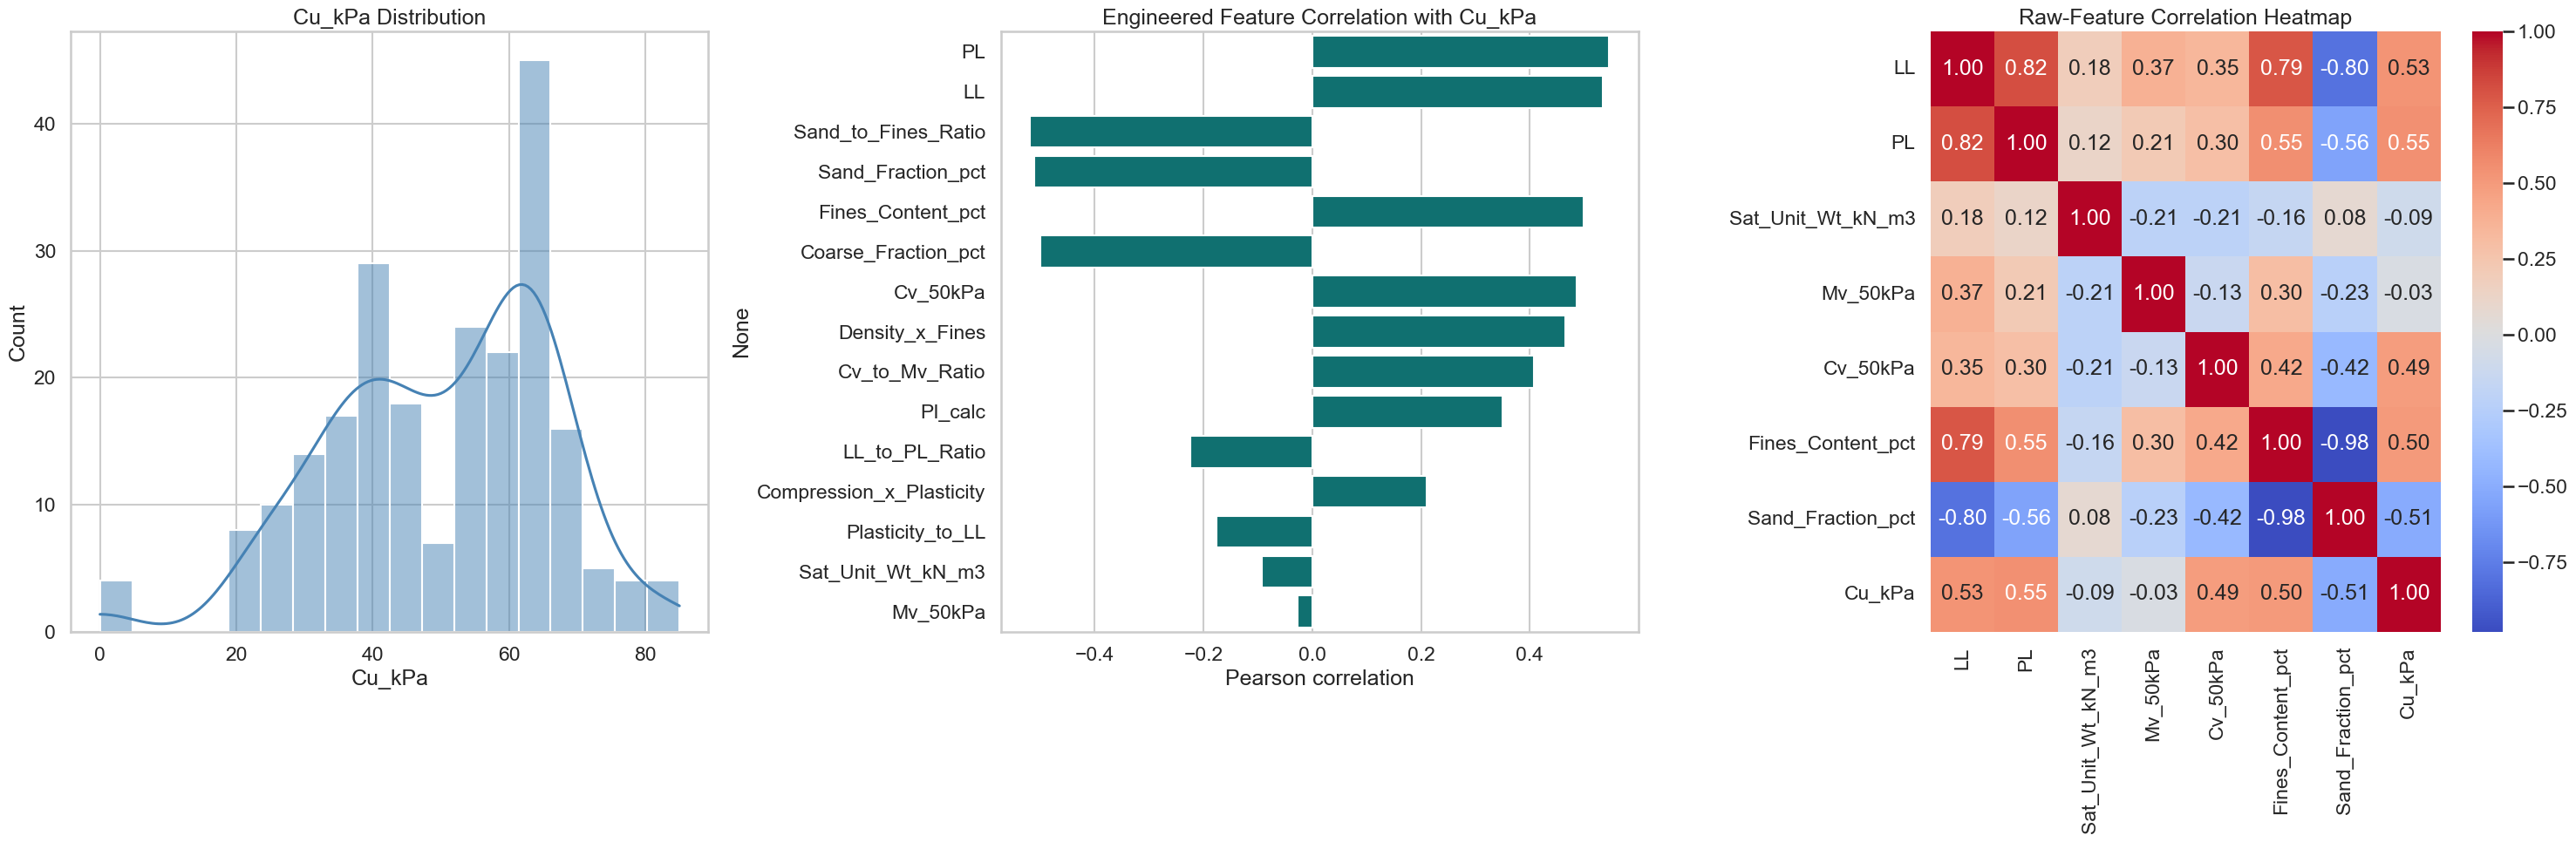

In [16]:
# Build a compact EDA panel so the target distribution and the strongest raw correlations are visible.
corr_with_target = (
    X.assign(Cu_kPa=y)
    .corr(numeric_only=True)['Cu_kPa']
    .drop('Cu_kPa')
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

sns.histplot(y, kde=True, bins=18, ax=axes[0], color='steelblue')
axes[0].set_title('Cu_kPa Distribution')
axes[0].set_xlabel('Cu_kPa')

sns.barplot(x=corr_with_target.values, y=corr_with_target.index, ax=axes[1], color='teal')
axes[1].set_title('Engineered Feature Correlation with Cu_kPa')
axes[1].set_xlabel('Pearson correlation')

heatmap_columns = [
    'LL',
    'PL',
    'Sat_Unit_Wt_kN_m3',
    'Mv_50kPa',
    'Cv_50kPa',
    'Fines_Content_pct',
    'Sand_Fraction_pct',
    TARGET_COLUMN,
]
sns.heatmap(data_df[heatmap_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Raw-Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## Model Comparison

The comparison uses shuffled 5-fold cross-validation. Two scaled linear baselines are included to anchor the problem, but the main expectation is that ensemble methods will capture the non-linear strength response more effectively.

In [17]:
# Use an explicit RMSE helper to stay compatible with sklearn builds that do not expose squared=False.
def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metric_frame(y_true, y_pred):
    return {
        'OOF_RMSE': root_mean_squared_error(y_true, y_pred),
        'OOF_MAE': float(mean_absolute_error(y_true, y_pred)),
        'OOF_R2': float(r2_score(y_true, y_pred)),
    }

def build_model_candidates():
    models = {
        'Linear Regression': Pipeline([
            ('scale', StandardScaler()),
            ('model', LinearRegression()),
        ]),
        'Ridge Regression': Pipeline([
            ('scale', StandardScaler()),
            ('model', Ridge(alpha=1.0)),
        ]),
        'Random Forest': RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            learning_rate=0.05,
            n_estimators=300,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    else:
        models['AdaBoost'] = AdaBoostRegressor(
            n_estimators=300,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    return models

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': 'r2',
}

evaluation_rows = []
oof_predictions = {}
model_candidates = build_model_candidates()

for model_name, model in model_candidates.items():
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    preds = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    oof_predictions[model_name] = preds

    row = {
        'Model': model_name,
        'CV_RMSE_Mean': -cv_scores['test_rmse'].mean(),
        'CV_RMSE_STD': cv_scores['test_rmse'].std(),
        'CV_MAE_Mean': -cv_scores['test_mae'].mean(),
        'CV_R2_Mean': cv_scores['test_r2'].mean(),
    }
    row.update(metric_frame(y, preds))
    evaluation_rows.append(row)

results_df = pd.DataFrame(evaluation_rows).sort_values('OOF_RMSE').reset_index(drop=True)
best_model_name = results_df.loc[0, 'Model']
best_model = clone(model_candidates[best_model_name])

display(results_df.round(4))
print(f'Best model based on OOF RMSE: {best_model_name}')

,Model,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean,CV_R2_Mean,OOF_RMSE,OOF_MAE,OOF_R2
0,Extra Trees,6.5043,1.8282,4.0747,0.8147,6.7639,4.0773,0.8262
1,XGBoost,6.7470,1.8990,4.3127,0.7997,7.0160,4.3174,0.8130
2,Gradient Boosting,7.0074,1.9227,4.5612,0.7865,7.2745,4.5648,0.7989
3,Random Forest,7.4620,1.8102,4.8170,0.7609,7.6860,4.8202,0.7756
4,Ridge Regression,11.7479,1.2194,9.0958,0.4455,11.8230,9.1024,0.4689
5,Linear Regression,11.7860,1.2582,9.0243,0.4404,11.8641,9.0306,0.4652


Best model based on OOF RMSE: Extra Trees


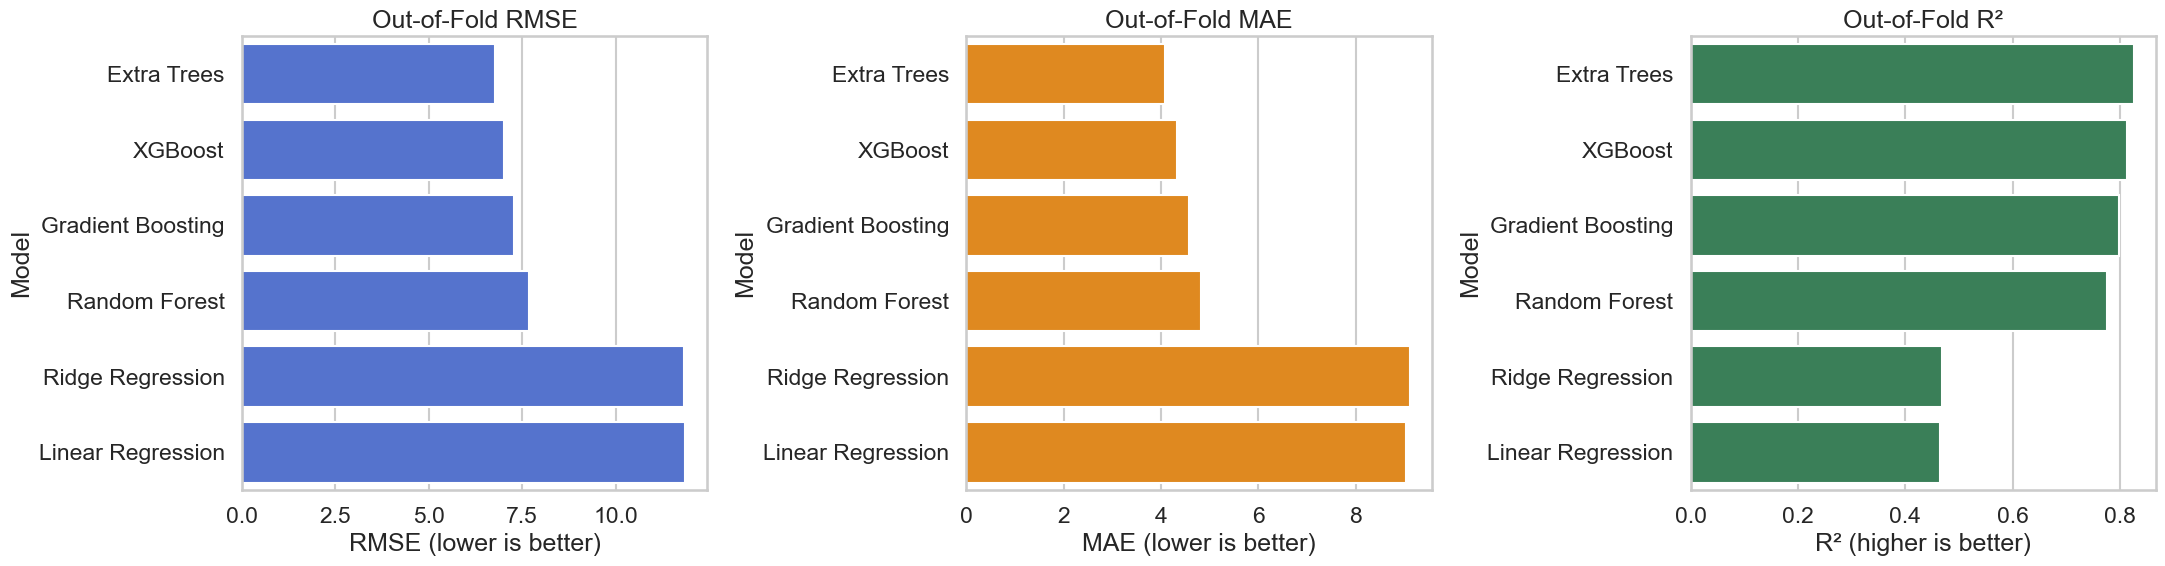

In [18]:
# Plot the model comparison so the ranking is easy to interpret at a glance.
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=results_df, x='OOF_RMSE', y='Model', ax=axes[0], color='royalblue')
axes[0].set_title('Out-of-Fold RMSE')
axes[0].set_xlabel('RMSE (lower is better)')

sns.barplot(data=results_df, x='OOF_MAE', y='Model', ax=axes[1], color='darkorange')
axes[1].set_title('Out-of-Fold MAE')
axes[1].set_xlabel('MAE (lower is better)')

sns.barplot(data=results_df, x='OOF_R2', y='Model', ax=axes[2], color='seagreen')
axes[2].set_title('Out-of-Fold R²')
axes[2].set_xlabel('R² (higher is better)')

plt.tight_layout()
plt.show()

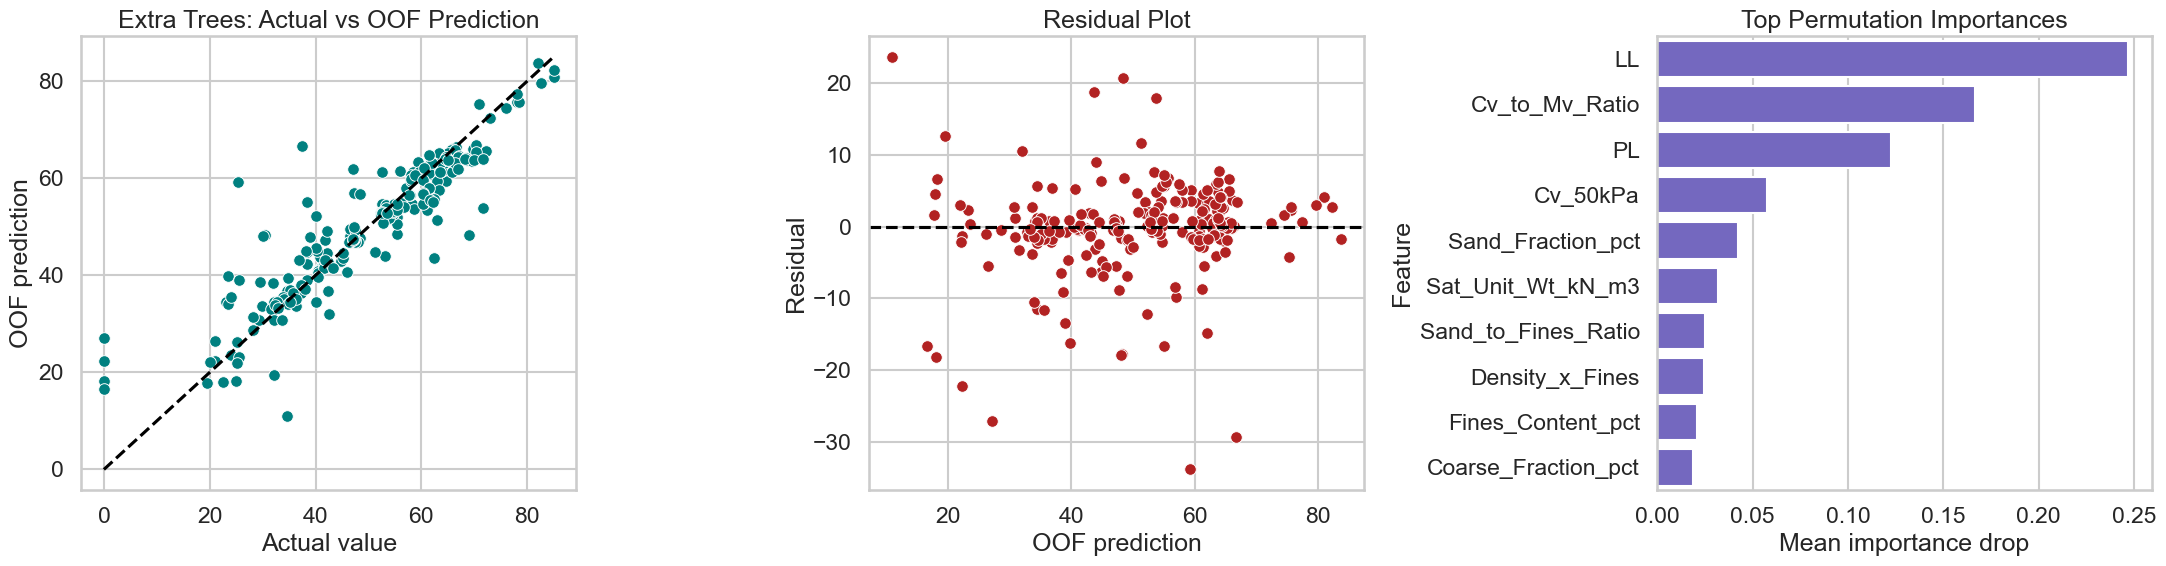

,value
Best model,Extra Trees
Comparison CSV,cu_model_comparison.csv
OOF predictions CSV,cu_oof_predictions.csv
Feature importance CSV,cu_feature_importance.csv
Best model artifact,cu_best_model.joblib


,Feature,Importance,Importance_STD
0,LL,0.2470,0.0223
1,Cv_to_Mv_Ratio,0.1666,0.0145
2,PL,0.1224,0.0133
3,Cv_50kPa,0.0578,0.0043
4,Sand_Fraction_pct,0.0424,0.0056
5,Sat_Unit_Wt_kN_m3,0.0318,0.0029
6,Sand_to_Fines_Ratio,0.0252,0.0033
7,Density_x_Fines,0.0243,0.0030
8,Fines_Content_pct,0.0210,0.0025
9,Coarse_Fraction_pct,0.0190,0.0021


In [19]:
# Fit the winning model on the full dataset, then inspect prediction quality and feature importance.
best_model.fit(X, y)
best_oof = oof_predictions[best_model_name]
residuals = y - best_oof

importance = permutation_importance(
    best_model,
    X,
    y,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance.importances_mean,
        'Importance_STD': importance.importances_std,
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(x=y, y=best_oof, ax=axes[0], color='teal', s=70, edgecolor='white')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--', color='black')
axes[0].set_title(f'{best_model_name}: Actual vs OOF Prediction')
axes[0].set_xlabel('Actual value')
axes[0].set_ylabel('OOF prediction')

sns.scatterplot(x=best_oof, y=residuals, ax=axes[1], color='firebrick', s=70, edgecolor='white')
axes[1].axhline(0.0, linestyle='--', color='black')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('OOF prediction')
axes[1].set_ylabel('Residual')

sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', ax=axes[2], color='slateblue')
axes[2].set_title('Top Permutation Importances')
axes[2].set_xlabel('Mean importance drop')

plt.tight_layout()
plt.show()

comparison_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_model_comparison.csv'
oof_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_oof_predictions.csv'
model_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_best_model.joblib'
importance_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_feature_importance.csv'

results_df.to_csv(comparison_path, index=False)
pd.DataFrame({
    'Actual': y,
    'OOF_Prediction': best_oof,
    'Residual': residuals,
}).to_csv(oof_path, index=False)
importance_df.to_csv(importance_path, index=False)
joblib.dump(best_model, model_path)

export_summary = pd.Series({
    'Best model': best_model_name,
    'Comparison CSV': comparison_path.name,
    'OOF predictions CSV': oof_path.name,
    'Feature importance CSV': importance_path.name,
    'Best model artifact': model_path.name,
})
display(export_summary.to_frame('value'))
display(importance_df.head(10).round(4))

## Takeaway

Use the exported comparison table to compare all models numerically and keep the saved best-model artifact for downstream prediction work. The importance chart in this notebook is descriptive rather than causal, but it still helps verify that the model is leaning on plausible strength-related drivers.